# Crowd Counting Hybrid Pipeline - Step-by-Step Visualization

This notebook demonstrates the hybrid crowd counting pipeline with detailed visualizations at each step.

## 1. Setup and Imports

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from crowd_counting_hybrid import build_background_from_empty_images, detect_heads_hybrid

# Configure matplotlib for better visualizations
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['image.cmap'] = 'gray'

## 2. Load Empty Beach Images (for Background Model)

In [4]:
empty_beach_images_paths = [
    '/Dev/Image-and-Video-Analysis/crowd-counting/data/1660798800.jpg',
    '/Dev/Image-and-Video-Analysis/crowd-counting/data/1660802400.jpg'
]

In [ ]:
# Prepare background from two empty images:
empty_imgs = [img for img in (cv2.imread(image_path) for image_path in empty_beach_images_paths) if img is not None]

## 3. Build Background Model

In [7]:
bg = build_background_from_empty_images(empty_imgs)  # shape (H, W), float32

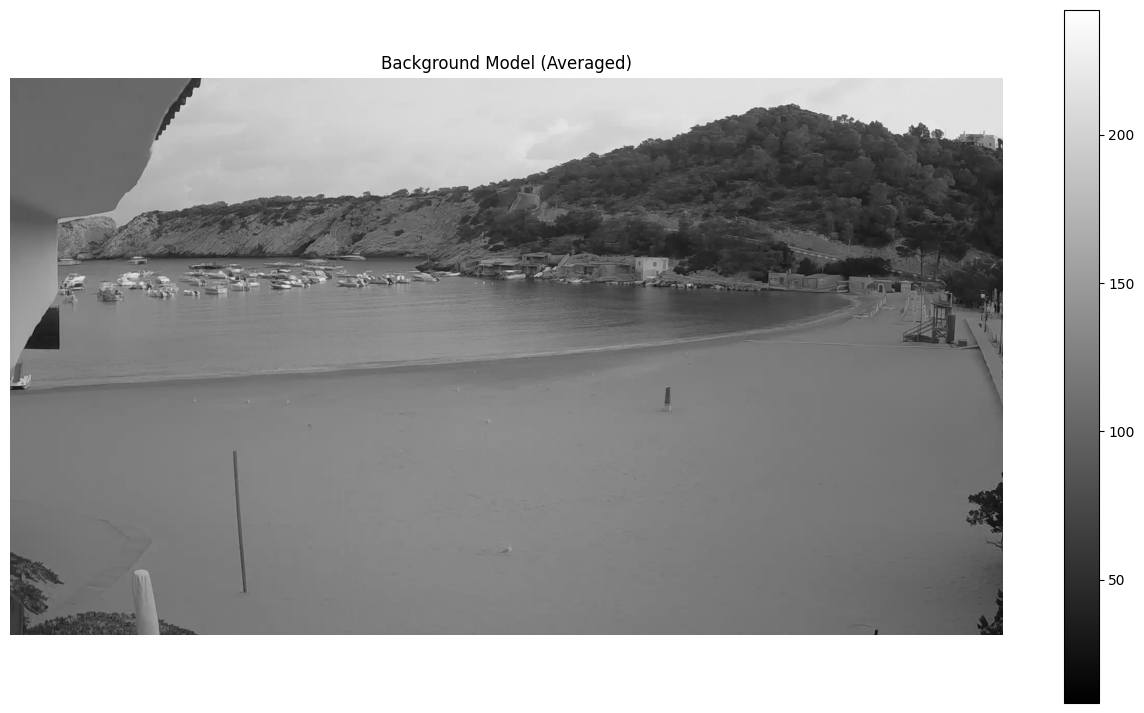

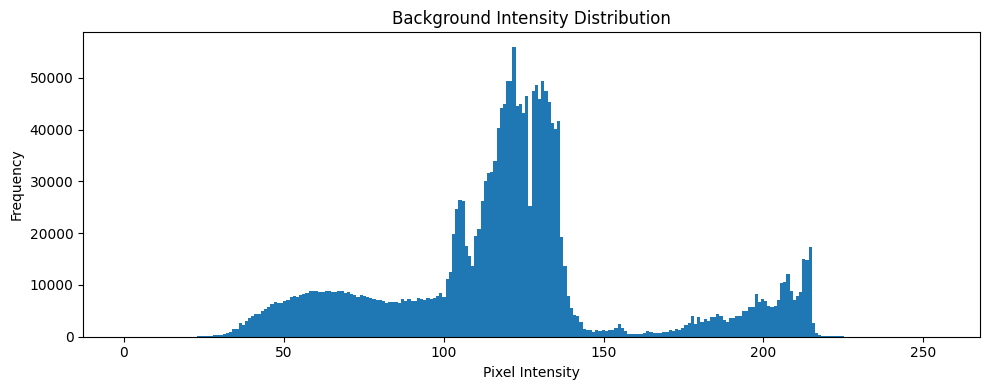

Background shape: (1080, 1920)
Background dtype: float32
Background range: [8.50, 242.00]


In [9]:
# Plot 'Background Model (Averaged)' in full size
plt.figure(figsize=(16, 9))
plt.imshow(bg, cmap='gray')
plt.title('Background Model (Averaged)')
plt.colorbar()
plt.axis('off')
plt.show()

# Plot 'Background Intensity Distribution' separately
plt.figure(figsize=(10, 4))
plt.hist(bg.ravel(), bins=256, range=(0, 255))
plt.title('Background Intensity Distribution')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Background shape: {bg.shape}")
print(f"Background dtype: {bg.dtype}")
print(f"Background range: [{bg.min():.2f}, {bg.max():.2f}]")

## 4. Load Test Image

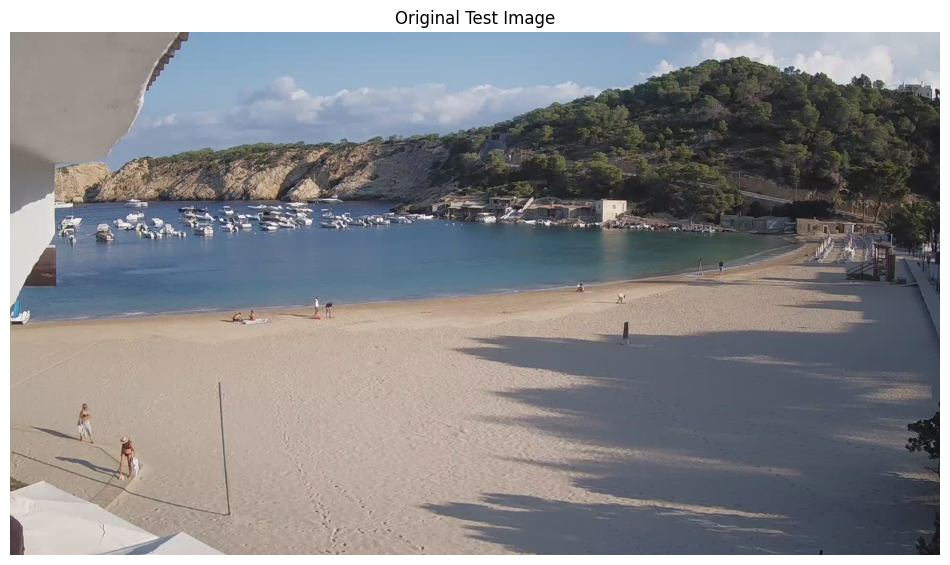

Test image shape: (1080, 1920, 3)


In [8]:
test_image_path = '/Dev/Image-and-Video-Analysis/crowd-counting/data/1660806000.jpg'

img = cv2.imread(test_image_path)

if img is None:
    raise ValueError(f"Could not load image from {test_image_path}")

# Display original image
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Test Image')
plt.axis('off')
plt.show()

print(f"Test image shape: {img.shape}")

## 5. Configure Pipeline Parameters

In [20]:
params = {
    'diff_threshold': 30.0,        # Sensitivity of foreground detection
    'clahe_clip': 3.0,             # CLAHE contrast limiting
    'clahe_tile': 8,               # CLAHE tile grid size
    'morph_kernel_size': 7,        # Size of morphological operations kernel
    'min_blob_area': 50,           # Minimum pixels for a valid detection
    'edge_low_thresh': 50,         # Canny lower threshold
    'edge_high_thresh': 150,       # Canny upper threshold
    'use_head_kernel': True,       # Enable circular head matching
    'head_kernel_radius': 4,       # Radius of circular head template
}

## 6. Step-by-Step Pipeline Execution with Visualization

In [21]:
from typing import List, Tuple
import cv2
import numpy as np

def visualize_pipeline_steps(image, background, params):
    """Execute pipeline and visualize each step"""
    
    # Convert to grayscale
    if image.ndim == 3:
        img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = image
    
    # --- STEP 1: CLAHE ---
    clahe = cv2.createCLAHE(
        clipLimit=params['clahe_clip'], 
        tileGridSize=(params['clahe_tile'], params['clahe_tile'])
    )
    img_clahe = clahe.apply(img_gray)
    
    # --- STEP 2: Background Subtraction ---
    diff = cv2.absdiff(
        img_clahe, 
        np.clip(background, 0, 255).astype(np.uint8)
    )
    _, mask = cv2.threshold(
        diff, 
        int(params['diff_threshold']), 
        255, 
        cv2.THRESH_BINARY
    )
    
    # --- STEP 3: Morphological Cleaning ---
    k = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, 
        (params['morph_kernel_size'], params['morph_kernel_size'])
    )
    mask_open = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)
    mask_close = cv2.morphologyEx(mask_open, cv2.MORPH_CLOSE, k)
    
    # --- STEP 4: Edge Detection ---
    edges = cv2.Canny(
        img_clahe, 
        threshold1=params['edge_low_thresh'], 
        threshold2=params['edge_high_thresh']
    )
    
    # --- STEP 5: Combine Mask and Edges ---
    edges_fg = cv2.bitwise_and(edges, mask_close)
    
    # --- STEP 6: Edge Refinement ---
    k2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    edges_fg_close = cv2.morphologyEx(edges_fg, cv2.MORPH_CLOSE, k2)
    edges_fg_fill = cv2.dilate(edges_fg_close, k2, iterations=1)
    
    # Fill contours
    contours, _ = cv2.findContours(
        edges_fg_fill, 
        cv2.RETR_EXTERNAL, 
        cv2.CHAIN_APPROX_SIMPLE
    )
    filled = np.zeros_like(mask_close)
    cv2.drawContours(filled, contours, -1, color=255, thickness=cv2.FILLED)
    
    # --- STEP 7: Final Candidate Mask ---
    candidates_mask = cv2.bitwise_and(mask_close, filled)
    
    # --- STEP 8: Head Kernel (if enabled) ---
    head_kernel = None
    if params['use_head_kernel']:
        r = params['head_kernel_radius']
        kr = 2 * r + 1
        y, x = np.ogrid[-r:r + 1, -r:r + 1]
        circle = (x * x + y * y) <= (r * r)
        head_kernel = circle.astype(np.uint8) * 255
    
    return {
        'gray': img_gray,
        'clahe': img_clahe,
        'diff': diff,
        'mask_raw': mask,
        'mask_open': mask_open,
        'mask_clean': mask_close,
        'edges': edges,
        'edges_fg': edges_fg,
        'edges_refined': edges_fg_fill,
        'filled': filled,
        'candidates': candidates_mask,
        'head_kernel': head_kernel
    }

# Execute pipeline
steps = visualize_pipeline_steps(img, bg, params)

## 7. Visualize All Pipeline Steps

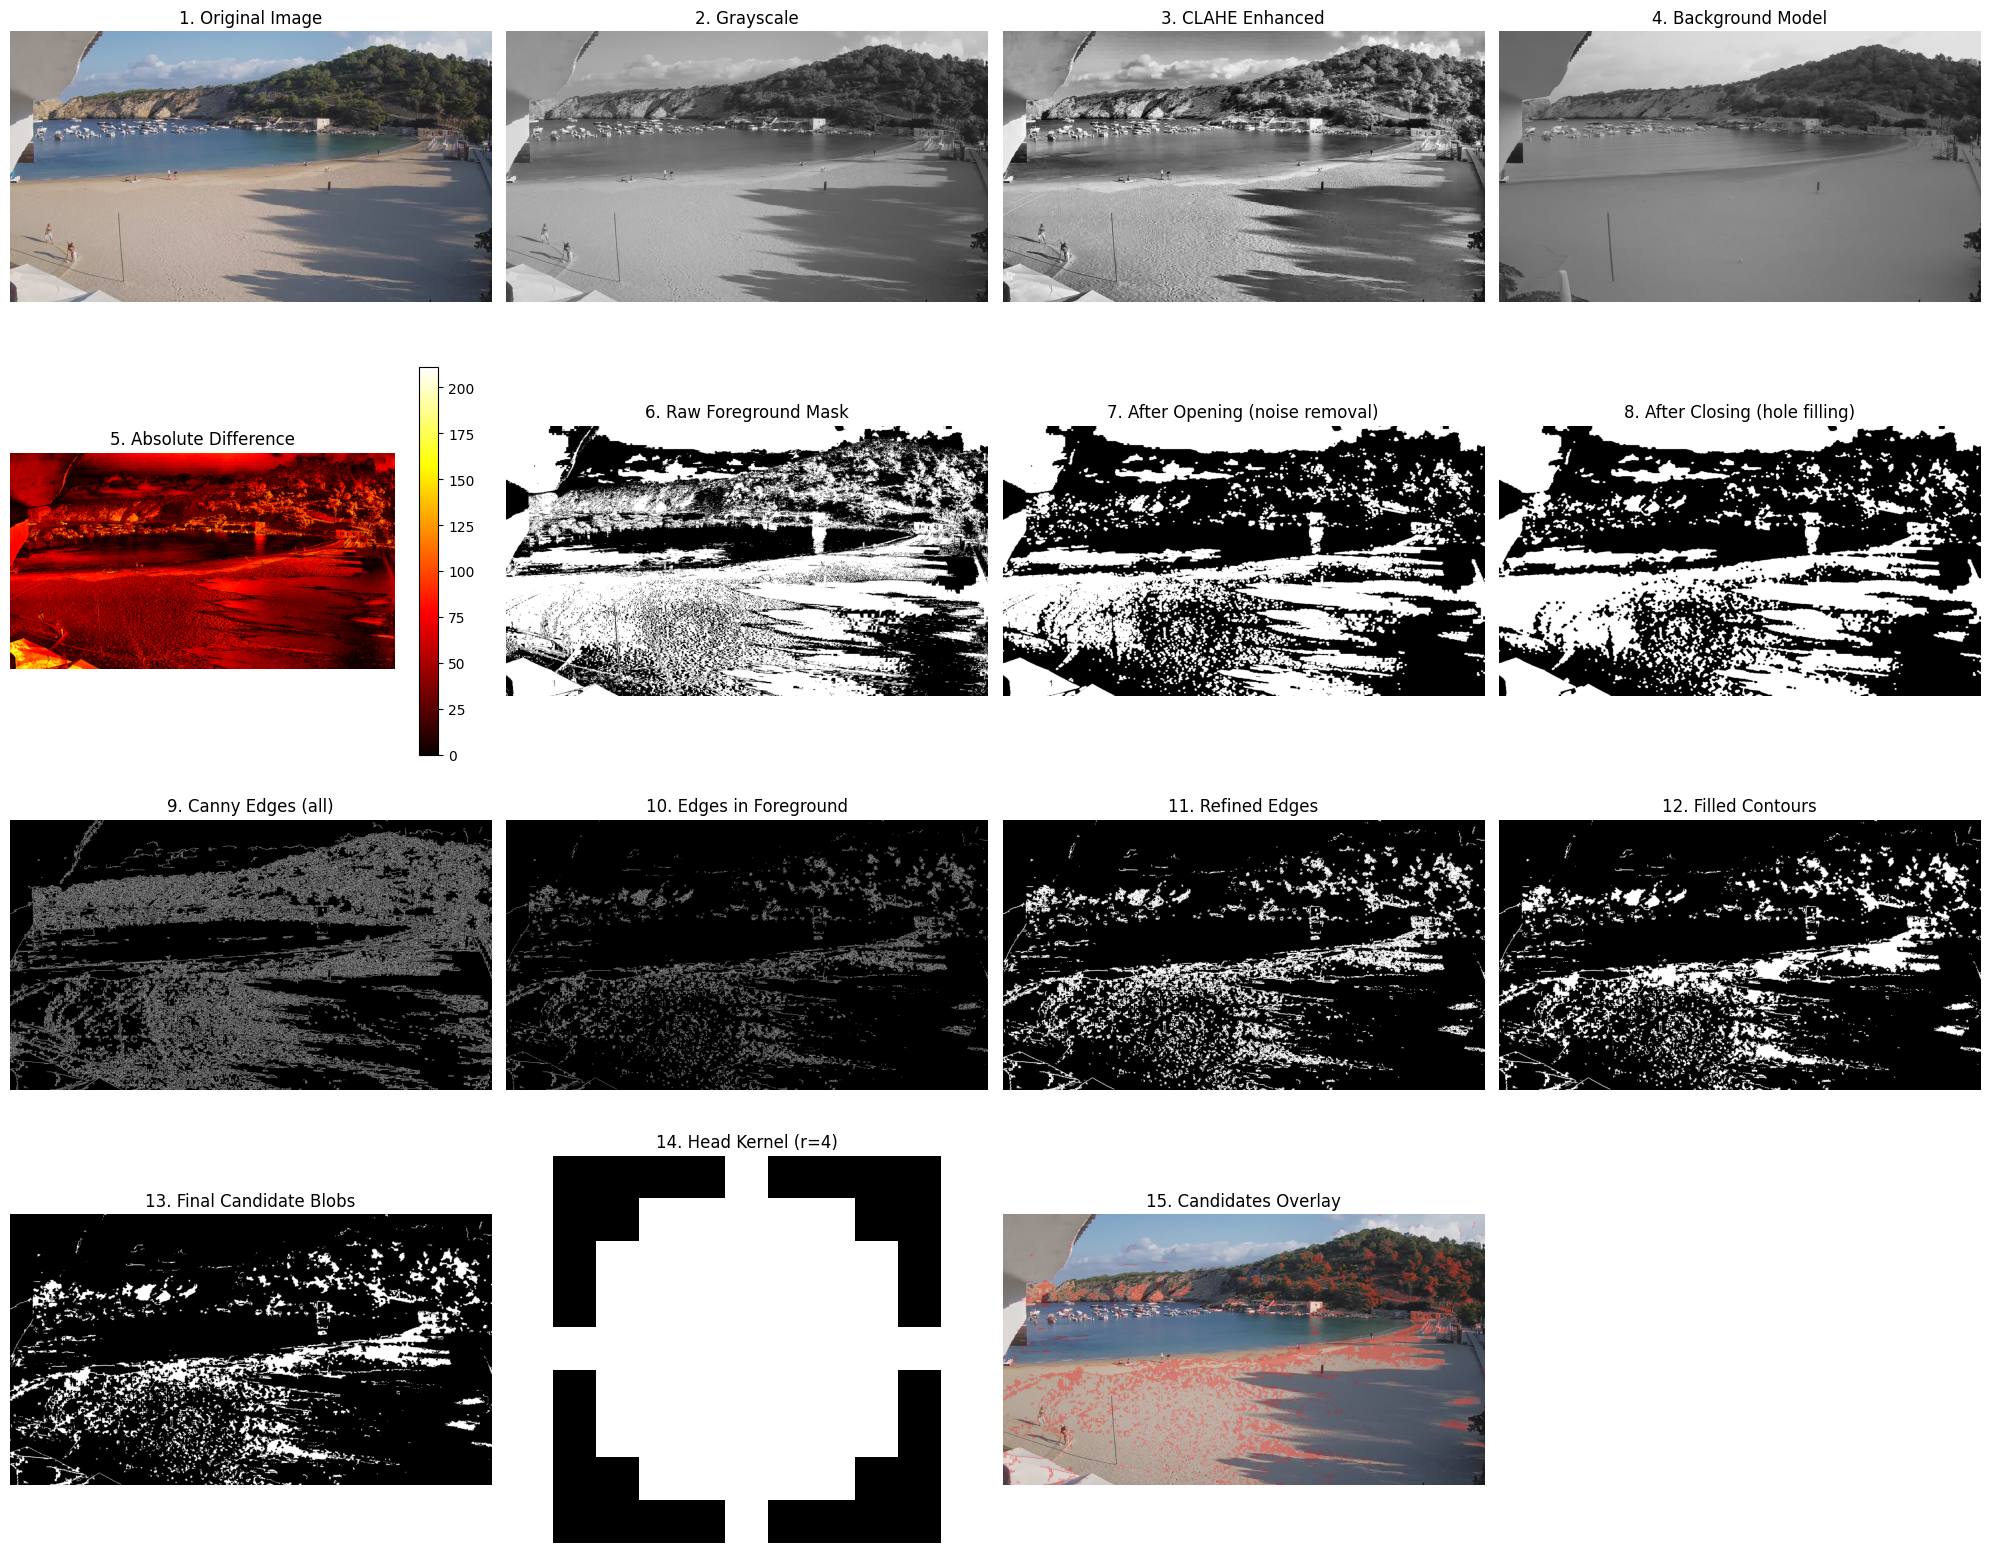

In [22]:
# Create comprehensive visualization
fig = plt.figure(figsize=(20, 16))

# Row 1: Original processing
plt.subplot(4, 4, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('1. Original Image')
plt.axis('off')

plt.subplot(4, 4, 2)
plt.imshow(steps['gray'], cmap='gray')
plt.title('2. Grayscale')
plt.axis('off')

plt.subplot(4, 4, 3)
plt.imshow(steps['clahe'], cmap='gray')
plt.title('3. CLAHE Enhanced')
plt.axis('off')

plt.subplot(4, 4, 4)
plt.imshow(bg, cmap='gray')
plt.title('4. Background Model')
plt.axis('off')

# Row 2: Background subtraction
plt.subplot(4, 4, 5)
plt.imshow(steps['diff'], cmap='hot')
plt.title('5. Absolute Difference')
plt.colorbar()
plt.axis('off')

plt.subplot(4, 4, 6)
plt.imshow(steps['mask_raw'], cmap='gray')
plt.title('6. Raw Foreground Mask')
plt.axis('off')

plt.subplot(4, 4, 7)
plt.imshow(steps['mask_open'], cmap='gray')
plt.title('7. After Opening (noise removal)')
plt.axis('off')

plt.subplot(4, 4, 8)
plt.imshow(steps['mask_clean'], cmap='gray')
plt.title('8. After Closing (hole filling)')
plt.axis('off')

# Row 3: Edge detection
plt.subplot(4, 4, 9)
plt.imshow(steps['edges'], cmap='gray')
plt.title('9. Canny Edges (all)')
plt.axis('off')

plt.subplot(4, 4, 10)
plt.imshow(steps['edges_fg'], cmap='gray')
plt.title('10. Edges in Foreground')
plt.axis('off')

plt.subplot(4, 4, 11)
plt.imshow(steps['edges_refined'], cmap='gray')
plt.title('11. Refined Edges')
plt.axis('off')

plt.subplot(4, 4, 12)
plt.imshow(steps['filled'], cmap='gray')
plt.title('12. Filled Contours')
plt.axis('off')

# Row 4: Final results
plt.subplot(4, 4, 13)
plt.imshow(steps['candidates'], cmap='gray')
plt.title('13. Final Candidate Blobs')
plt.axis('off')

if steps['head_kernel'] is not None:
    plt.subplot(4, 4, 14)
    plt.imshow(steps['head_kernel'], cmap='gray')
    plt.title(f'14. Head Kernel (r={params["head_kernel_radius"]})')
    plt.axis('off')

plt.subplot(4, 4, 15)
# Overlay mask on original
overlay = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
overlay[steps['candidates'] > 0] = [255, 0, 0]  # Red overlay
plt.imshow(cv2.addWeighted(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), 0.7, overlay, 0.3, 0))
plt.title('15. Candidates Overlay')
plt.axis('off')

plt.tight_layout()
plt.show()